<a href="https://colab.research.google.com/github/juliandavidsilvaguzman-star/Proyecto-estad-sticas-de-Youtube-Avances-II/blob/main/youtube_nlp_mlops_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción del desempeño de vídeos de YouTube mediante NLP

**Dataset:** YouTube Statistics, de Kaggle  
**Objetivo de esta etapa:** acceso, perfilado, calidad, suficiencia, mejora y preparación reproducible de los datos conforme a MLOps.

El cuaderno construye un **baseline reproducible** para predecir `Views` o `Likes` a partir del texto y las propiedades agregadas de los comentarios. La predicción es asociativa, no causal. Debido a que los comentarios se observan después de publicar el vídeo, el modelo sirve para estimar desempeño desde señales tempranas o actuales, no antes de la publicación.

## 1. Decisiones metodológicas

- Unidad de análisis: un vídeo.
- Unión: `videos-stats.csv` con `comments.csv` por `Video ID`.
- Texto: concatenación de los comentarios disponibles por vídeo.
- Objetivos posibles: `Views`, `Likes` y, con precaución, `Comments`.
- Transformación del objetivo: `log1p`, por la asimetría habitual de métricas de popularidad.
- División: entrenamiento/prueba por vídeo, sin compartir el mismo vídeo entre particiones.
- Baseline: mediana del conjunto de entrenamiento.
- Modelo NLP: TF-IDF de palabras + TF-IDF de caracteres + variables agregadas de comentarios + Ridge.
- Métricas: MAE y RMSE en escala logarítmica; MAE, RMSE, R² y RMSLE en escala original.

**Riesgos que deben documentarse:** muestra de comentarios limitada a los más relevantes, sesgo hacia comentarios con interacción, posible desalineación temporal entre comentarios y métricas del vídeo, idioma no identificado, valores `-1` como dato no disponible y ausencia de una marca temporal de extracción.

In [16]:
# 2. Instalación e importaciones
!pip -q install kagglehub pandera joblib

import json, hashlib, re, unicodedata, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import kagglehub

from scipy.stats import spearmanr, kruskal
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, mean_squared_log_error
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
DATASET_HANDLE = 'advaypatil/youtube-statistics'
TARGET = 'Views'  # Cambiar por 'Likes' para ejecutar el segundo caso
ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

In [17]:
# 3. Acceso reproducible al dataset desde Kaggle
# En Colab, kagglehub puede solicitar autenticación si el recurso la requiere.
data_dir = Path(kagglehub.dataset_download(DATASET_HANDLE))
print('Ruta local:', data_dir)
print('Archivos:', [p.name for p in data_dir.rglob('*') if p.is_file()])

def find_csv(fragment):
    matches = [p for p in data_dir.rglob('*.csv') if fragment.lower() in p.name.lower()]
    if not matches:
        raise FileNotFoundError(f'No se encontró un CSV que contenga: {fragment}')
    return matches[0]

videos_path = find_csv('video')
comments_path = find_csv('comment')
videos_raw = pd.read_csv(videos_path)
comments_raw = pd.read_csv(comments_path)
print('videos:', videos_raw.shape, '| comments:', comments_raw.shape)
display(videos_raw.head(3), comments_raw.head(3))

Using Colab cache for faster access to the 'youtube-statistics' dataset.
Ruta local: /kaggle/input/youtube-statistics
Archivos: ['videos-stats.csv', 'comments.csv']
videos: (1881, 8) | comments: (18409, 5)


,Unnamed: 0,Title,Video ID,Published At,Keyword,Likes,Comments,Views
0,0,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,2022-08-23,tech,3407.0,672.0,135612.0
1,1,The most EXPENSIVE thing I own.,b3x28s61q3c,2022-08-24,tech,76779.0,4306.0,1758063.0
2,2,My New House Gaming Setup is SICK!,4mgePWWCAmA,2022-08-23,tech,63825.0,3338.0,1564007.0


,Unnamed: 0,Video ID,Comment,Likes,Sentiment
0,0,wAZZ-UWGVHI,Let's not forget that Apple Pay in 2014 requir...,95.0,1.0
1,1,wAZZ-UWGVHI,Here in NZ 50% of retailers don’t even have co...,19.0,0.0
2,2,wAZZ-UWGVHI,I will forever acknowledge this channel with t...,161.0,2.0


In [18]:
# 4. Linaje y versionado básico de datos

def sha256_file(path, chunk_size=1024*1024):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()

manifest = {
    'dataset_handle': DATASET_HANDLE,
    'downloaded_at_utc': datetime.now(timezone.utc).isoformat(),
    'files': {
        videos_path.name: {'sha256': sha256_file(videos_path), 'rows': int(len(videos_raw))},
        comments_path.name: {'sha256': sha256_file(comments_path), 'rows': int(len(comments_raw))}
    }
}
(ARTIFACTS_DIR / 'data_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print(json.dumps(manifest, indent=2)[:1200])

{
  "dataset_handle": "advaypatil/youtube-statistics",
  "downloaded_at_utc": "2026-10-07T01:31:08.368885+00:00",
  "files": {
    "videos-stats.csv": {
      "sha256": "09b52f4ac493ffb7a07e64eca489c31afd43cc540398bf626988eaa3cebf930a",
      "rows": 1881
    },
    "comments.csv": {
      "sha256": "bc78f5fbddcf57cfcde8609ce35a23658c2eb98fca05d1ffe62fff65a20f651b",
      "rows": 18409
    }
  }
}


In [19]:
# 5. Normalización de nombres y validación de esquema

def normalize_columns(df):
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    return out

videos = normalize_columns(videos_raw)
comments = normalize_columns(comments_raw)

required_videos = {'Video ID', 'Title', 'Published At', 'Keyword', 'Likes', 'Comments', 'Views'}
required_comments = {'Video ID', 'Comment', 'Likes', 'Sentiment'}
missing_v = required_videos - set(videos.columns)
missing_c = required_comments - set(comments.columns)
assert not missing_v, f'Columnas ausentes en vídeos: {missing_v}'
assert not missing_c, f'Columnas ausentes en comentarios: {missing_c}'

videos['Published At'] = pd.to_datetime(videos['Published At'], errors='coerce')
for c in ['Likes', 'Comments', 'Views']:
    videos[c] = pd.to_numeric(videos[c], errors='coerce')
for c in ['Likes', 'Sentiment']:
    comments[c] = pd.to_numeric(comments[c], errors='coerce')
comments['Comment'] = comments['Comment'].astype('string')

print('Esquema validado.')

Esquema validado.


In [20]:
# 6. Informe de calidad de datos

def quality_table(df, name):
    return pd.DataFrame({
        'dataset': name,
        'columna': df.columns,
        'tipo': [str(df[c].dtype) for c in df.columns],
        'nulos': [int(df[c].isna().sum()) for c in df.columns],
        'pct_nulos': [float(df[c].isna().mean()*100) for c in df.columns],
        'unicos': [int(df[c].nunique(dropna=True)) for c in df.columns]
    })

quality = pd.concat([quality_table(videos, 'videos'), quality_table(comments, 'comments')], ignore_index=True)
display(quality)

checks = {
    'videos_filas': len(videos),
    'comments_filas': len(comments),
    'video_id_duplicado_en_videos': int(videos['Video ID'].duplicated().sum()),
    'filas_duplicadas_videos': int(videos.duplicated().sum()),
    'filas_duplicadas_comments': int(comments.duplicated().sum()),
    'comments_sin_texto': int(comments['Comment'].isna().sum() + comments['Comment'].fillna('').str.strip().eq('').sum()),
    'sentiment_fuera_de_0_1_2': int((~comments['Sentiment'].isin([0,1,2]) & comments['Sentiment'].notna()).sum()),
    'video_ids_comments_sin_video': int((~comments['Video ID'].isin(videos['Video ID'])).sum()),
    'video_ids_sin_comments': int((~videos['Video ID'].isin(comments['Video ID'])).sum()),
}
display(pd.Series(checks, name='valor').to_frame())
quality.to_csv(ARTIFACTS_DIR / 'data_quality_columns.csv', index=False)
pd.Series(checks).to_json(ARTIFACTS_DIR / 'data_quality_checks.json', indent=2)

,dataset,columna,tipo,nulos,pct_nulos,unicos
0,videos,Unnamed: 0,int64,0,0.000000,1881
1,videos,Title,object,0,0.000000,1854
2,videos,Video ID,object,0,0.000000,1869
3,videos,Published At,datetime64[ns],0,0.000000,757
4,videos,Keyword,object,0,0.000000,41
5,videos,Likes,float64,2,0.106326,1827
6,videos,Comments,float64,2,0.106326,1372
7,videos,Views,float64,2,0.106326,1868
8,comments,Unnamed: 0,int64,0,0.000000,18409
9,comments,Video ID,object,0,0.000000,1869


,valor
videos_filas,1881
comments_filas,18409
video_id_duplicado_en_videos,12
filas_duplicadas_videos,0
filas_duplicadas_comments,0
comments_sin_texto,2
sentiment_fuera_de_0_1_2,0
video_ids_comments_sin_video,0
video_ids_sin_comments,0


In [21]:
# 7. Limpieza controlada
# -1 significa métrica no visible o comentarios deshabilitados, por lo que se convierte en NaN.
for c in ['Likes', 'Comments']:
    videos.loc[videos[c] < 0, c] = np.nan
videos.loc[videos['Views'] < 0, 'Views'] = np.nan
comments.loc[comments['Likes'] < 0, 'Likes'] = np.nan

videos = videos.drop_duplicates(subset=['Video ID'], keep='first').copy()
comments = comments.drop_duplicates().copy()
comments['Comment'] = comments['Comment'].fillna('').str.replace(r'\s+', ' ', regex=True).str.strip()
comments = comments[comments['Comment'].ne('')].copy()
comments = comments[comments['Sentiment'].isin([0,1,2])].copy()

# No se eliminan emojis, signos ni mayúsculas aquí: pueden aportar señal al vectorizador de caracteres.
print(videos.shape, comments.shape)

(1869, 8) (18408, 5)


,n_comments_observed
count,1869.000000
mean,9.849117
std,1.371836
min,1.000000
10%,10.000000
25%,10.000000
50%,10.000000
75%,10.000000
90%,10.000000
95%,10.000000


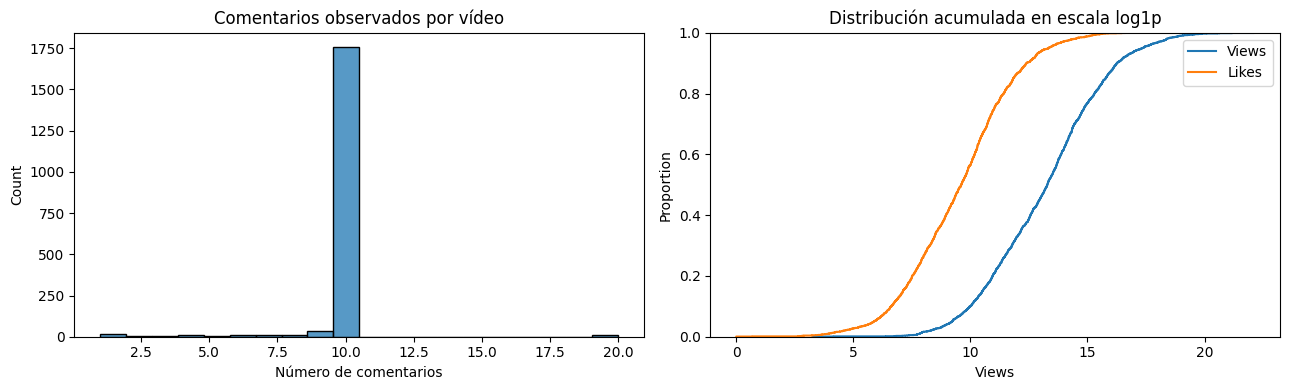

Vídeos con comentarios: 1869
Cobertura sobre vídeos: 1.0


In [22]:
# 8. ¿Son suficientes los datos?
coverage = comments.groupby('Video ID').size().rename('n_comments_observed')
coverage_summary = coverage.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99])
display(coverage_summary.to_frame())

fig, ax = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(coverage, bins=20, ax=ax[0])
ax[0].set_title('Comentarios observados por vídeo')
ax[0].set_xlabel('Número de comentarios')

for target in ['Views','Likes']:
    sns.ecdfplot(np.log1p(videos[target].dropna()), label=target, ax=ax[1])
ax[1].set_title('Distribución acumulada en escala log1p')
ax[1].legend()
plt.tight_layout()
plt.show()

print('Vídeos con comentarios:', coverage.size)
print('Cobertura sobre vídeos:', round(coverage.size / videos['Video ID'].nunique(), 4))

### Criterio de suficiencia

No debe decidirse solo por el número de filas. Se evaluará mediante:

1. Cobertura de vídeos con comentarios.
2. Distribución de comentarios por vídeo.
3. Porcentaje de objetivos ausentes o censurados.
4. Estabilidad de validación cruzada.
5. Diferencia frente al baseline.
6. Curva de aprendizaje: si el error sigue mejorando al aumentar la muestra, conviene recolectar más datos.
7. Representatividad por palabra clave, fecha e idioma.

Si cada vídeo solo tiene una selección pequeña de comentarios relevantes, el corpus puede ser útil para una prueba académica, pero no demuestra por sí solo capacidad de generalización en producción.

In [8]:
# 9. Ingeniería de características a nivel de vídeo

def safe_std(s):
    value = s.std()
    return 0.0 if pd.isna(value) else float(value)

comment_features = comments.groupby('Video ID').agg(
    comment_text=('Comment', lambda s: ' [SEP] '.join(s.astype(str))),
    n_comments_observed=('Comment', 'size'),
    avg_comment_length=('Comment', lambda s: s.str.len().mean()),
    std_comment_length=('Comment', lambda s: safe_std(s.str.len())),
    avg_comment_likes=('Likes', 'mean'),
    max_comment_likes=('Likes', 'max'),
    positive_ratio=('Sentiment', lambda s: (s == 2).mean()),
    neutral_ratio=('Sentiment', lambda s: (s == 1).mean()),
    negative_ratio=('Sentiment', lambda s: (s == 0).mean()),
    sentiment_mean=('Sentiment', 'mean'),
    sentiment_std=('Sentiment', safe_std),
).reset_index()

df = videos.merge(comment_features, on='Video ID', how='inner')
df['title_text'] = df['Title'].fillna('').astype(str)
df['combined_text'] = (df['comment_text'].fillna('') + ' [TITLE] ' + df['title_text']).str.strip()

# Variables temporales para EDA, no se incluyen por defecto en el modelo centrado en comentarios.
df['publish_year'] = df['Published At'].dt.year
df['publish_month'] = df['Published At'].dt.month
print('Tabla analítica:', df.shape)
display(df.head(2))

Tabla analítica: (1869, 23)


,Unnamed: 0,Title,Video ID,Published At,Keyword,Likes,Comments,Views,comment_text,n_comments_observed,...,max_comment_likes,positive_ratio,neutral_ratio,negative_ratio,sentiment_mean,sentiment_std,title_text,combined_text,publish_year,publish_month
0,0,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,2022-08-23,tech,3407.0,672.0,135612.0,Let's not forget that Apple Pay in 2014 requir...,10,...,161.0,0.4,0.4,0.2,1.2,0.788811,Apple Pay Is Killing the Physical Wallet After...,Let's not forget that Apple Pay in 2014 requir...,2022,8
1,1,The most EXPENSIVE thing I own.,b3x28s61q3c,2022-08-24,tech,76779.0,4306.0,1758063.0,"Wow, you really went to town on the PSU test r...",10,...,2808.0,0.9,0.0,0.1,1.8,0.632456,The most EXPENSIVE thing I own.,"Wow, you really went to town on the PSU test r...",2022,8


In [23]:
# 10. Análisis estadísticos no triviales
# 10.1 Correlación de Spearman con bootstrap del IC 95%
def bootstrap_spearman(x, y, n_boot=2000, seed=42):
    pair = pd.DataFrame({'x':x, 'y':y}).dropna()
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(pair), len(pair))
        vals.append(spearmanr(pair.iloc[idx]['x'], pair.iloc[idx]['y']).statistic)
    rho = spearmanr(pair['x'], pair['y']).statistic
    return rho, np.nanpercentile(vals, [2.5, 97.5])

stats_rows = []
for feature in ['sentiment_mean','positive_ratio','negative_ratio','avg_comment_likes','avg_comment_length']:
    for target in ['Views','Likes']:
        rho, ci = bootstrap_spearman(df[feature], df[target])
        stats_rows.append({'feature':feature,'target':target,'spearman_rho':rho,'ci_low':ci[0],'ci_high':ci[1]})
stats_df = pd.DataFrame(stats_rows)
display(stats_df)

# 10.2 Kruskal-Wallis: diferencias de vistas entre terciles de positividad
valid = df[['positive_ratio','Views']].dropna().copy()
valid['positive_group'] = pd.qcut(valid['positive_ratio'].rank(method='first'), 3, labels=['bajo','medio','alto'])
groups = [np.log1p(g['Views'].values) for _, g in valid.groupby('positive_group', observed=True)]
kw = kruskal(*groups)
print('Kruskal-Wallis sobre log1p(Views):', kw)

# 10.3 Popularidad normalizada por keyword para reducir el efecto de categoría
df['views_keyword_z'] = df.groupby('Keyword')['Views'].transform(
    lambda s: (np.log1p(s) - np.log1p(s).mean()) / (np.log1p(s).std() or 1)
)
display(df.groupby('Keyword').agg(videos=('Video ID','nunique'), median_views=('Views','median'), median_sentiment=('sentiment_mean','median')).sort_values('videos', ascending=False).head(15))

,feature,target,spearman_rho,ci_low,ci_high
0,sentiment_mean,Views,0.126282,0.084847,0.169851
1,sentiment_mean,Likes,0.154162,0.109463,0.197447
2,positive_ratio,Views,0.145704,0.104943,0.188474
3,positive_ratio,Likes,0.170050,0.124818,0.214027
4,negative_ratio,Views,-0.022536,-0.069814,0.022706
5,negative_ratio,Likes,-0.054444,-0.100156,-0.008407
6,avg_comment_likes,Views,0.713693,0.686160,0.739240
7,avg_comment_likes,Likes,0.769698,0.744930,0.792633
8,avg_comment_length,Views,0.018203,-0.031393,0.068059
9,avg_comment_length,Likes,0.048212,0.000888,0.098332


Kruskal-Wallis sobre log1p(Views): KruskalResult(statistic=np.float64(37.61784693448767), pvalue=np.float64(6.782476967697499e-09))


,videos,median_views,median_sentiment
Keyword,,,
cnn,50,474328.5,0.55
mrbeast,50,65074742.5,1.70
tutorial,50,2817913.5,1.80
trolling,50,611040.0,1.25
marvel,50,1373022.5,1.50
interview,50,1152823.0,1.75
game development,50,319505.0,1.70
data science,50,268809.0,1.80
crypto,50,23410.5,1.40


## 11. Prevención de fuga de información

Para predecir `Views` no se usan `Likes` ni `Comments` del vídeo, porque son métricas de desempeño simultáneas y producirían una estimación optimista. Las variables `Likes` de los comentarios también requieren una decisión temporal: pueden usarse si el escenario es una actualización posterior a la publicación; deben excluirse si se pretende predecir con los primeros comentarios antes de que estos acumulen interacción.

El modelo siguiente conserva las variables de interacción de comentarios, pero están centralizadas en `NUMERIC_FEATURES`, de modo que pueden retirarse para un escenario estrictamente temprano.

In [24]:
# 12. Preparación del conjunto de modelado
TEXT_FEATURE = 'combined_text'
NUMERIC_FEATURES = [
    'n_comments_observed', 'avg_comment_length', 'std_comment_length',
    'avg_comment_likes', 'max_comment_likes',
    'positive_ratio', 'neutral_ratio', 'negative_ratio',
    'sentiment_mean', 'sentiment_std'
]

model_df = df[[TEXT_FEATURE] + NUMERIC_FEATURES + [TARGET, 'Video ID']].dropna(subset=[TARGET]).copy()
model_df = model_df[model_df[TARGET] >= 0].reset_index(drop=True)

train_df, test_df = train_test_split(model_df, test_size=0.20, random_state=RANDOM_STATE)
X_train = train_df[[TEXT_FEATURE] + NUMERIC_FEATURES]
y_train = train_df[TARGET]
X_test = test_df[[TEXT_FEATURE] + NUMERIC_FEATURES]
y_test = test_df[TARGET]
print('Train:', X_train.shape, 'Test:', X_test.shape, 'Target:', TARGET)

Train: (1493, 11) Test: (374, 11) Target: Views


In [25]:
# 13. Pipelines reproducibles: baseline y NLP
word_tfidf = TfidfVectorizer(
    lowercase=True, strip_accents='unicode', ngram_range=(1,2),
    min_df=2, max_df=0.98, max_features=25000, sublinear_tf=True
)
char_tfidf = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3,5), min_df=2,
    max_features=15000, sublinear_tf=True
)

preprocessor = ColumnTransformer([
    ('word_tfidf', word_tfidf, TEXT_FEATURE),
    ('char_tfidf', char_tfidf, TEXT_FEATURE),
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), NUMERIC_FEATURES)
])

baseline = TransformedTargetRegressor(
    regressor=DummyRegressor(strategy='median'),
    func=np.log1p, inverse_func=np.expm1
)

nlp_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('features', preprocessor),
        ('regressor', Ridge(alpha=10.0))
    ]),
    func=np.log1p, inverse_func=np.expm1
)

In [26]:
# 14. Entrenamiento y evaluación

def regression_metrics(y_true, y_pred):
    y_pred = np.maximum(np.asarray(y_pred), 0)
    y_true = np.asarray(y_true)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'RMSLE': np.sqrt(mean_squared_log_error(y_true, y_pred)),
        'MAE_log1p': mean_absolute_error(np.log1p(y_true), np.log1p(y_pred)),
        'RMSE_log1p': root_mean_squared_error(np.log1p(y_true), np.log1p(y_pred))
    }

results = []
for name, model in [('baseline_mediana', baseline), ('tfidf_ridge', nlp_model)]:
    model.fit(X_train, y_train)
    pred = np.maximum(model.predict(X_test), 0)
    row = {'model': name, **regression_metrics(y_test, pred)}
    results.append(row)

results_df = pd.DataFrame(results).sort_values('RMSE_log1p')
display(results_df)
results_df.to_csv(ARTIFACTS_DIR / f'metrics_{TARGET.lower()}.csv', index=False)

,model,MAE,RMSE,R2,RMSLE,MAE_log1p,RMSE_log1p
1,tfidf_ridge,1.742038e+07,2.136419e+08,-0.003949,1.953648,1.565333,1.953648
0,baseline_mediana,1.796334e+07,2.139382e+08,-0.006735,2.416824,1.966001,2.416824


In [27]:
# 15. Estabilidad mediante validación cruzada
# Se evalúa en log1p con métricas negativas de sklearn, luego se cambia el signo.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'mae':'neg_mean_absolute_error', 'rmse':'neg_root_mean_squared_error', 'r2':'r2'}
cv_out = cross_validate(nlp_model, model_df[[TEXT_FEATURE] + NUMERIC_FEATURES], model_df[TARGET], cv=cv, scoring=scoring, n_jobs=-1)
cv_summary = pd.DataFrame({
    'métrica': ['MAE','RMSE','R2'],
    'media': [-cv_out['test_mae'].mean(), -cv_out['test_rmse'].mean(), cv_out['test_r2'].mean()],
    'desviación': [cv_out['test_mae'].std(), cv_out['test_rmse'].std(), cv_out['test_r2'].std()]
})
display(cv_summary)

,métrica,media,desviación
0,MAE,4.853581e+24,9.707161e+24
1,RMSE,9.373821e+25,1.874764e+26
2,R2,-5.612643e+36,1.122529e+37


,fracción_train,n_train,RMSE_log1p
0,0.2,299,2.055003
1,0.4,597,1.976608
2,0.6,896,2.033801
3,0.8,1194,1.993373
4,1.0,1493,1.953641


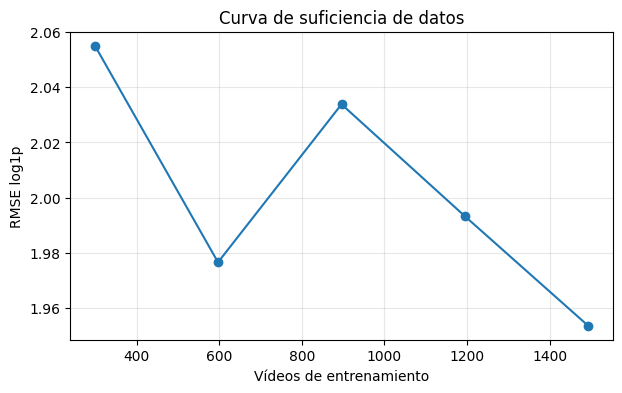

In [29]:
# 16. Curva de suficiencia de datos
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
curve = []
for frac in fractions:
    subset = train_df.sample(frac=frac, random_state=RANDOM_STATE)
    m = nlp_model
    m.fit(subset[[TEXT_FEATURE] + NUMERIC_FEATURES], subset[TARGET])
    p = np.maximum(m.predict(X_test), 0)
    curve.append({'fracción_train': frac, 'n_train': len(subset), 'RMSE_log1p': regression_metrics(y_test,p)['RMSE_log1p']})
curve_df = pd.DataFrame(curve)
display(curve_df)
plt.figure(figsize=(7,4))
plt.plot(curve_df['n_train'], curve_df['RMSE_log1p'], marker='o')
plt.xlabel('Vídeos de entrenamiento')
plt.ylabel('RMSE log1p')
plt.title('Curva de suficiencia de datos')
plt.grid(alpha=.3)
plt.show()

In [28]:
# 17. Registro local de artefactos del experimento
best_model = nlp_model.fit(model_df[[TEXT_FEATURE] + NUMERIC_FEATURES], model_df[TARGET])
joblib.dump(best_model, ARTIFACTS_DIR / f'model_{TARGET.lower()}_tfidf_ridge.joblib')

model_card = {
    'target': TARGET,
    'unit_of_analysis': 'video',
    'training_rows': int(len(model_df)),
    'features': {'text': TEXT_FEATURE, 'numeric': NUMERIC_FEATURES},
    'random_state': RANDOM_STATE,
    'limitations': [
        'Los comentarios son posteriores a la publicación.',
        'La selección de comentarios relevantes puede introducir sesgo.',
        'No hay garantía de alineación temporal entre comentarios y métricas.',
        'El modelo es predictivo y no causal.',
        'Debe validarse en datos más recientes y externos antes de producción.'
    ]
}
(ARTIFACTS_DIR / f'model_card_{TARGET.lower()}.json').write_text(json.dumps(model_card, indent=2, ensure_ascii=False), encoding='utf-8')
print('Artefactos generados:', [p.name for p in ARTIFACTS_DIR.iterdir()])

Artefactos generados: ['data_quality_columns.csv', 'model_card_views.json', 'data_manifest.json', 'model_views_tfidf_ridge.joblib', 'data_quality_checks.json', 'metrics_views.csv']


## 18. Cómo mejorar los datos

1. **Aumentar cobertura temporal:** recolectar comentarios y métricas en ventanas fijas, por ejemplo, 1, 6, 24 y 72 horas desde la publicación.
2. **Evitar sesgo de selección:** no limitarse a los comentarios “más relevantes”; usar una muestra cronológica o aleatoria y conservar el criterio de muestreo.
3. **Guardar marcas temporales:** fecha del comentario, fecha de extracción y edad del vídeo al medir vistas/likes.
4. **Incorporar idiomas:** detectar idioma y evaluar por segmento; un único vectorizador puede no tratar todos los idiomas igual.
5. **Añadir metadatos seguros:** duración, canal, suscriptores al publicar, categoría, hora de publicación y longitud del título. No usar variables observadas después del horizonte de predicción.
6. **Crear snapshots:** conservar datos raw inmutables, versión curada y tabla analítica con hash, esquema y fecha.
7. **Corregir representación:** muestreo estratificado por `Keyword`, periodo e intervalos de popularidad.
8. **Definir el horizonte:** “predecir vistas” es insuficiente; debe especificarse vistas acumuladas a una edad concreta del vídeo.
9. **Recoger más comentarios por vídeo:** evaluar la ganancia incremental con curvas de aprendizaje y ablación.
10. **Validación externa y temporal:** entrenar en publicaciones antiguas y probar en publicaciones posteriores.

## Conclusión de la primera etapa

El dataset permite construir un baseline académico para `Views` y `Likes` a partir de comentarios. Su principal limitación no es solo el tamaño, sino la selección restringida de comentarios y la falta de sincronización temporal. Por ello, el resultado debe presentarse como una prueba de viabilidad y no como un sistema listo para producción. La decisión de suficiencia debe basarse en cobertura, estabilidad entre particiones, mejora sobre el baseline y curva de aprendizaje.